# **Dataset Generation for IROS Diffusion**

In [1]:
from pathlib import Path
import pickle
from typing import Any, Callable, Optional

import numpy as np
from numpy.random import Generator
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from tqdm import tqdm

from bloodmoon.coords import angle2shift, shift2pos, pos2shift
from bloodmoon.images import argmax
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.mask import decode, variance, snratio
from bloodmoon.optim import model_shadowgram
import darksun as ds

import imgmaker as mgm

ds.show.set_figures_darkbkg()

- The whole dataset is composed of:
    * *data*:
        - array `[N, 1, H_sg, W_sg]` representing the $N$ source shadowgrams acting as ground-truth images for the joint-diffusion process;

        - array `[N, 1, 1, 3]` representing the respective $N$ source parameters (local-frame coords, collected photons) acting as ground-truth parameters for the joint-diffusion process;

    * *conditioning*:
        - array `[N, 1, H_spsf, W_spsf]` representing the $N$ source PSF heat-maps acting as images conditioning for the joint-diffusion process;

        - array `[N, 1, 1, 3]` representing the respective $N$ source PSF parameters (extracted local-frame coords at peak, peak counts) acting as parameters conditioning for the joint-diffusion process;

    * a `dict[str, NDArray]` containing a LEM-X coded-mask camera main arrays:
        - detector sensitivity
        - coded-mask
        - reconstruction matrix
        - balancing
        - sources instrumental variances (needed for counts normalisation during data pre-processing)

    * a `dict[str, int | float]` containing a LEM-X coded-mask camera geometry specifics.

<br>

- Currently, the imaging is performed at upsampling $(\text{up}_{fine}, \text{up}_{coarse}) = 2, 1$ to limit the computational cost (eventually consider higher upsamplings for improved discretisation and resolution, coupled with external `DownSampler`s and `UpSampler`s for diffusion interface).

<br>

- The tests on the IROS Diffusion framework are carried out starting from an ideal instrumental setup, analysing how the joint-diffusion process responds to each instrumental effect and sequentially introducing realisms:

    * \[**current**\] *1st TEST*: full-ideal camera, with thin mask plate (no vignetting), infinite detector spatial resolution (no counts dispersion) and infinite detector density (no inclined penetration from off-axis photons);

    * *2nd TEST*: semi-ideal camera, with thick mask plate (yes vignetting), infinite detector spatial resolution (no counts dispersion) and infinite detector density (no inclined penetration from off-axis photons);

    * *3rd TEST*: semi-ideal camera, with thick mask plate (yes vignetting), finite detector spatial resolution (yes counts dispersion) but infinite detector density (no inclined penetration from off-axis photons);

    * *4th TEST*: real camera, with thick mask plate (yes vignetting), finite detector spatial resolution (yes counts dispersion) and finite detector density (yes inclined penetration from off-axis photons);

In [2]:
def gen_coords(camera: CodedMaskCamera, n: int, rng: Optional[Generator] = None) -> NDArray:
    """Generates `n` random camera local-frame coords in `84° x 84°` FoV."""
    if rng is None: rng = np.random.default_rng()
    lim = angle2shift(camera, 42)
    return rng.uniform(-lim, lim, (n, 2))

def gen_shadowgrams(
    camera: CodedMaskCamera,
    coords: NDArray,
    rmin: float = 0.2,
    rmax: float = 10,
    vignetting: bool | Callable = True,
    psfy: bool | Callable = True,
    rng: Optional[Generator] = None,
) -> NDArray:
    """Generates `n` source shadowgrams, storing them in arr of shape `[n, d_h, d_w]`."""
    if rng is None:
        rng = np.random.default_rng()

    n = coords.shape[0]
    rates = rng.uniform(rmin, rmax, n)
    out = np.empty((n, 1, *camera.shape_detector), dtype=np.float64)

    loop = tqdm(enumerate(zip(rates, coords)), total=n, desc='Generating Shadowgrams')
    for idx, (r, crd) in loop:
        sx, sy = crd
        poiss = rng.poisson(r, size=camera.shape_detector)
        sg = model_shadowgram(camera, sx, sy, vignetting, psfy, normalise=False)
        out[idx, 0] = poiss * sg

    return out

def extract_groundtruth_params(coords: NDArray, shadowgrams: NDArray) -> NDArray:
    """
    Concatenates source coords and counts (obtained from input `shadowgrams`)
    and reshapes resulting array to extract ground-truth parameters.
    """
    counts = shadowgrams.sum(axis=(-2, -1))
    return np.concat((coords, counts), axis=-1).reshape(coords.shape[0], 1, 1, 3)

In [3]:
def find_boxmax(arr: NDArray, centre: tuple[int, int], boxsize: int | tuple = 5) -> tuple[int, int]:
    """Finds the argmax of given arr in a box centered around `pos`."""
    box = (boxsize, boxsize) if isinstance(boxsize, int) else boxsize
    rcut, ccut = map(lambda idx, b: slice(idx - b, idx + b + 1), centre, box)
    by, bx = box
    p, q = centre
    n, m = argmax(arr[rcut, ccut])
    return p - by + n, q - bx + m

def extract_from_shadowgrams(
    camera: CodedMaskCamera,
    shadowgrams: NDArray,
    coords: NDArray,
    crp: tuple[int, int] = (38, 6),
) -> tuple[NDArray, NDArray, NDArray]:
    """
    Extracts source PSF heat-maps, initial parameters (both for conditioning),
    and instrumental variance value at peak intensity.
    """
    n = coords.shape[0]
    cy, cx = crp

    psfs = np.empty((n, 1, 2 * cy + 1, 2 * cx + 1), dtype=shadowgrams.dtype)
    params = np.empty((n, 1, 1, 3), dtype=np.float64)
    peaks_var = np.empty(n, dtype=np.float64)

    loop = tqdm(enumerate(zip(shadowgrams, coords)), total=n, desc='Extracting from SGs')
    for idx, (sg, crds) in loop:
        sky = decode(camera, sg[0])
        varmap = variance(camera, sg[0])

        _idxs = shift2pos(camera, *crds)
        peak_pos = find_boxmax(sky, _idxs, (10, 5))

        psfs[idx, 0] = ds.crop(sky, peak_pos, crp)
        params[idx, 0, 0, :-1] = pos2shift(camera, *peak_pos)
        params[idx, 0, 0, -1] = sky[*peak_pos]
        peaks_var[idx] = varmap[*peak_pos]

    return psfs, params, peaks_var

In [4]:
def gather_dataset(
    camera: CodedMaskCamera,
    data: tuple[NDArray, NDArray],
    condition: tuple[NDArray, NDArray],
    var_values: NDArray,
) -> dict[str, Any]:
    """Gather all objs being part of the IROS Diffusion dataset."""
    out: dict[str, Any] = {}

    sgs, pars = data
    out['data'] = {'imgs': sgs, 'params': pars}
    psfs, init_pars = condition
    out['condition'] = {'imgs': psfs, 'params': init_pars}
    
    out['camera'] = {
        'specs': camera.specs.__dict__,
        'upsampling': {
            'ups_fine': camera.upscale_x,
            'ups_coarse': camera.upscale_y,
        },
        'var_values': var_values,
        'mask': camera.mask,
        'decoder': camera.decoder,
        'bulk': camera.bulk,
        'balancing': camera.balancing,
        'data_shape': {
            'detector': camera.shape_detector,
            'mask': camera.shape_mask,
            'sky': camera.shape_sky,
        },
        'bins': {
            'detector': (camera.bins_detector.x, camera.bins_detector.y),
            'mask': (camera.bins_mask.x, camera.bins_mask.y),
            'sky': (camera.bins_sky.x, camera.bins_sky.y),
        }
    }

    return out

def save_dataset(data: dict[str, Any], save_to: str | Path, overwrite: bool = False, **kwargs) -> None:
    """Saves dataset in `pickle` format."""
    if Path(save_to).exists() and not overwrite:
        print('Dataset already saved!')
        return
    print('Saving...')
    with open(save_to, "wb") as handle:
        pickle.dump(data, handle, protocol=pickle.HIGHEST_PROTOCOL, **kwargs)
    print('Dataset saved!')
    return

def load_dataset(filepath: str | Path, **kwargs) -> dict[str, Any]:
    """Loads dataset from `pickle` file."""
    if not Path(filepath).exists():
        raise FileNotFoundError(f"Input file {filepath} does not exists.")
    print('Loading...')
    with open(filepath, "rb") as handle:
        dataset = pickle.load(handle, **kwargs)
    print('Dataset loaded!')
    return dataset

In [ ]:
def gen_in_step(
    camera: CodedMaskCamera,
    batch: int,
    repeat: int,
    rng: Optional[Generator] = None,
) -> None:
    """
    Generates multiple datasets with `batch` elements in `repeat` steps.
    This implementantion is used to save memory.

    TODO: shift to batches in `gen_shadowgrams()` and `extract_from_shadowgrams()`
          for speed-up and more memory saving (batch approach like torch's DataLoaders,
          where an obj yields batches of elements from total array).
    NOTE: on Lenovo Legion 5 (i7), `gen_shadowgrams()` takes ~30s for 1000 samples,
          while `extract_from_shadowgrams()` takes ~5min.
    """
    if rng is None:
        rng = np.random.default_rng()

    for step in range(repeat):
        print(f'\n# ----------------- STEP: {step + 1}, BATCH: {batch} -----------------')
        # generate ground-truth shadowgrams and parameters (source coords + total collected photons) 
        coords = gen_coords(camera, batch, rng)
        sgs = gen_shadowgrams(camera, coords, vignetting=VIGNETTING, psfy=PSFY, rng=rng)
        gt_params = extract_groundtruth_params(coords, sgs)

        # generate condition SPSFs and parameters (SPSF peak coords + reconstructed peak counts)
        psfs, init_params, peaks_var = extract_from_shadowgrams(camera, sgs, coords)

        # gather data to make dataset and save
        save_to: str = f"{BASE_PATH}/test_dataset_ID{step + 1}_nels{batch}.pt"
        dataset = gather_dataset(camera, (sgs, gt_params), (psfs, init_params), peaks_var)
        save_dataset(dataset, save_to)

    return

In [9]:
BASE_PATH: str = "/mnt/d/PhD_AASS/Coding/Images_fits"
MASK_PATH: str = f"{BASE_PATH}/mask_NTHT_20260129_CORRECTED.fits"
UPS_X, UPS_Y = 2, 1
DATASET: str = 'detected'

VIGNETTING: bool | Callable = False
PSFY: bool | Callable = mgm.config_psfy_flag(DATASET)

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

In [ ]:
# - For this test (full-ideal camera), the source shadowgrams will be generated manually by approximating sources emission
#   with Poisson noise, and then multiplying for the shifted mask pattern to perform the projection onto the detector plane.
# - This configuration allows to neglect momentarily ad-hoc observations performed with the WISEMAN simulator.
#   NOTE: this approximation is valid only in the first case as I'm assuming a full-ideal setup.

rnd_gen: Generator = np.random.default_rng()

N: int = 1

In [ ]:
gen_in_step(wfm, 1000, 5, rnd_gen)

# ----------------- STEP: 1, BATCH: 1000 -----------------


Generating Shadowgrams:   0%|          | 0/1000 [00:00<?, ?it/s]

Extracting from SGs: 100%|██████████| 1000/1000 [05:13<00:00,  3.19it/s]


Saving...
Dataset saved!
# ----------------- STEP: 2, BATCH: 1000 -----------------


Generating Shadowgrams:  24%|██▍       | 240/1000 [00:08<00:26, 28.61it/s]


KeyboardInterrupt: 

In [ ]:
save_to: str = f"{BASE_PATH}/test_dataset.pt"

# generate ground-truth shadowgrams and parameters (source coords + total collected photons) 
coords = gen_coords(wfm, N, rnd_gen)
sgs = gen_shadowgrams(wfm, coords, vignetting=VIGNETTING, psfy=PSFY, rng=rnd_gen)
gt_params = extract_groundtruth_params(coords, sgs)

# generate condition SPSFs and parameters (SPSF peak coords + reconstructed peak counts)
psfs, init_params, peaks_var = extract_from_shadowgrams(wfm, sgs, coords)

# gather data to make dataset and save
dataset = gather_dataset(wfm, (sgs, gt_params), (psfs, init_params), peaks_var)
save_dataset(dataset, save_to)

MemoryError: Unable to allocate 14.5 GiB for an array with shape (5000, 308, 1264) and data type float64

In [ ]:
# tests

assert False

In [ ]:
def get_px_rate(camera: CodedMaskCamera, flx: NDArray) -> NDArray:
    """Computes the counts rate from given `flx` [ph / s / cm2] on detector pixels."""
    # pixel area in [cm^2]
    px_area: float = (
        1e-2 * camera.specs.mask_deltax * camera.specs.mask_deltay / np.prod(camera.upscale_f)
    )
    return flx * px_area


def show_mat(m: NDArray, title: str = None, **kwargs) -> None:
    mat = plt.matshow(m, origin='lower', **kwargs)
    if title is not None: plt.title(title)
    plt.colorbar(mat, location='right', shrink=0.8, pad=0.05)
    plt.show()
    return


from bloodmoon.optim import _shift_mask_pattern, _process_mask_pattern, _extract_detector
def get_sg(
    camera: CodedMaskCamera,
    shift_x: float,
    shift_y: float,
    vignetting: bool | Callable[[CodedMaskCamera, NDArray, float, float], NDArray],
    psfy: bool | Callable[[CodedMaskCamera, NDArray], NDArray],
) -> NDArray:
    """
    Generates shadowgram for a point source.
    """
    # shift camera mask pattern wrt source local-frame coords
    mask_shifted = _shift_mask_pattern(camera, shift_x, shift_y)
    # apply instrumental effects
    mask_projected = _process_mask_pattern(
        camera, mask_shifted, shift_x, shift_y, vignetting, psfy,
    )
    # extract normalised source detector image
    detector = _extract_detector(camera, mask_projected, normalise=False)
    return detector


# def gen_poisson_noise(
#     camera: CodedMaskCamera,
#     n: int,
#     rmin: float = 0.2,
#     rmax: float = 10,
#     rng: Optional[Generator] = None,
# ) -> NDArray:
#     """
#     Generates array of shape `[n, d_h, d_w]` with `n` Poisson noise arrays
#     whose mean rate is defined by uniform distr between `rmin` and `rmax`.
#     """
#     if rng is None: rng = np.random.default_rng()
#     rates = rng.uniform(rmin, rmax, n)
#     p = [rng.poisson(lam=r, size=(1, *camera.shape_detector)) for r in rates]
#     return np.concat(p, axis=0)

In [ ]:
rmin, rmax, n = 3, 10, 1

# flx = rnd_gen.uniform(fmin, fmax, n)
# px_rates = get_px_rate(wfm, flx)

px_rates = rnd_gen.uniform(rmin, rmax, n)

p = rnd_gen.poisson(lam=1, size=wfm.shape_detector)
# p = p / p.sum()

In [ ]:
px_rates, p.sum(), p.mean(), p.std()

(array([4.57522281]),
 np.int64(389224),
 np.float64(0.9997739602169982),
 np.float64(1.0010551263391867))

In [ ]:
tx, ty = 10.3, 10.7   # [deg]

sx, sy = map(lambda theta: angle2shift(wfm, theta), (tx, ty))
sg = get_sg(wfm, sx, sy, VIGNETTING, PSFY)

In [ ]:
detector = sg * p

detector.sum(), detector.mean(), detector.std()

(np.float64(124991.79467839595),
 np.float64(0.32105816075126364),
 np.float64(0.6930839622633226))

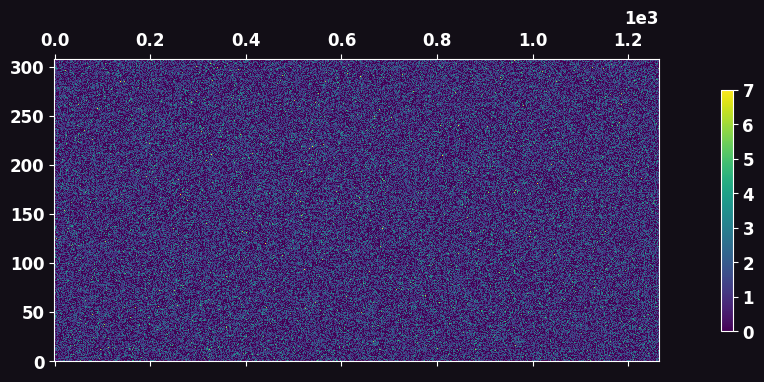

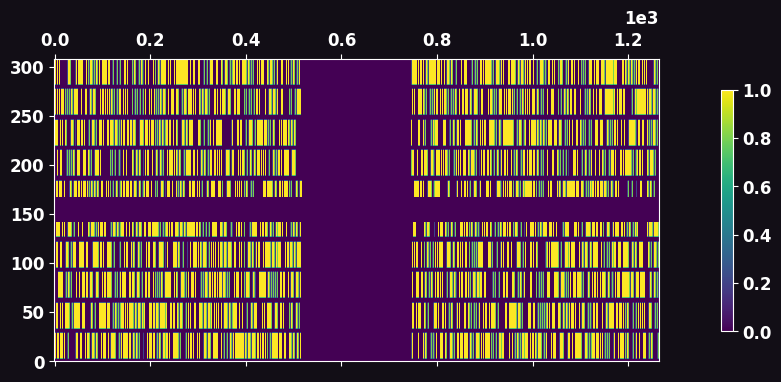

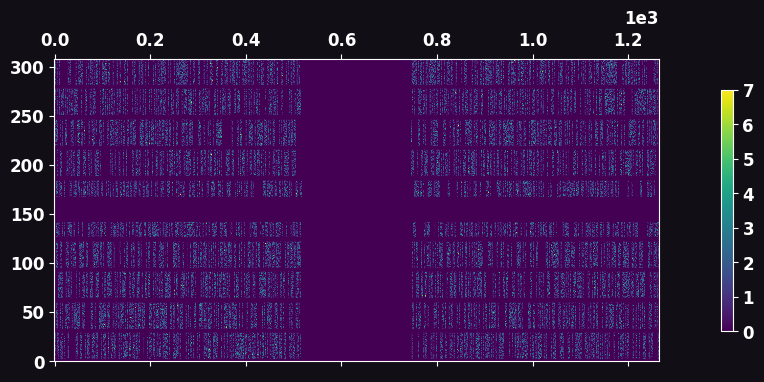

In [ ]:
aspect = 0.5 * wfm.shape_detector[1] / wfm.shape_detector[0]

for arr in (p, sg, detector):
    show_mat(arr, aspect=aspect)

In [ ]:
from bloodmoon.coords import shift2pos
from bloodmoon.images import argmax

def find_boxmax(sky: NDArray, centre: tuple[int, int], boxsize: int = 5) -> tuple[int, int]:
    """Finds the argmax of given sky in a box centered around `pos`."""
    rcut, ccut = map(lambda idx: slice(idx - boxsize, idx + boxsize + 1), centre)
    p, q = centre
    n, m = argmax(sky[rcut, ccut])
    return p - boxsize + n, q - boxsize + m

def extract_spsf(
    camera: CodedMaskCamera,
    sky: NDArray,
    coords: tuple[float, float],
    crp: tuple[int, int] = (36, 4),
) -> NDArray:
    """
    Extracts source PSF from sky, centered around peak position.
    NOTE: peak position may not be the same as input position.
    """
    idxs = shift2pos(camera, *coords)
    y, x = find_boxmax(sky, idxs)
    crpy, crpx = crp
    rows, cols = slice(y - crpy, y + crpy + 1), slice(x - crpx, x + crpx + 1)
    return sky[rows, cols]

skymap = decode(wfm, detector)
varmap = variance(wfm, detector)
snrmap = snratio(skymap, varmap)

In [ ]:
spsf = extract_spsf(wfm, skymap, coords=(sx, sy))
src_snr = extract_spsf(wfm, snrmap, coords=(sx, sy))

# for (arr, title) in ((detector, 'Shadowgram'), (spsf, 'Source PSF'), (src_snr, 'Source SNR')):
#     show_mat(arr, title=title)

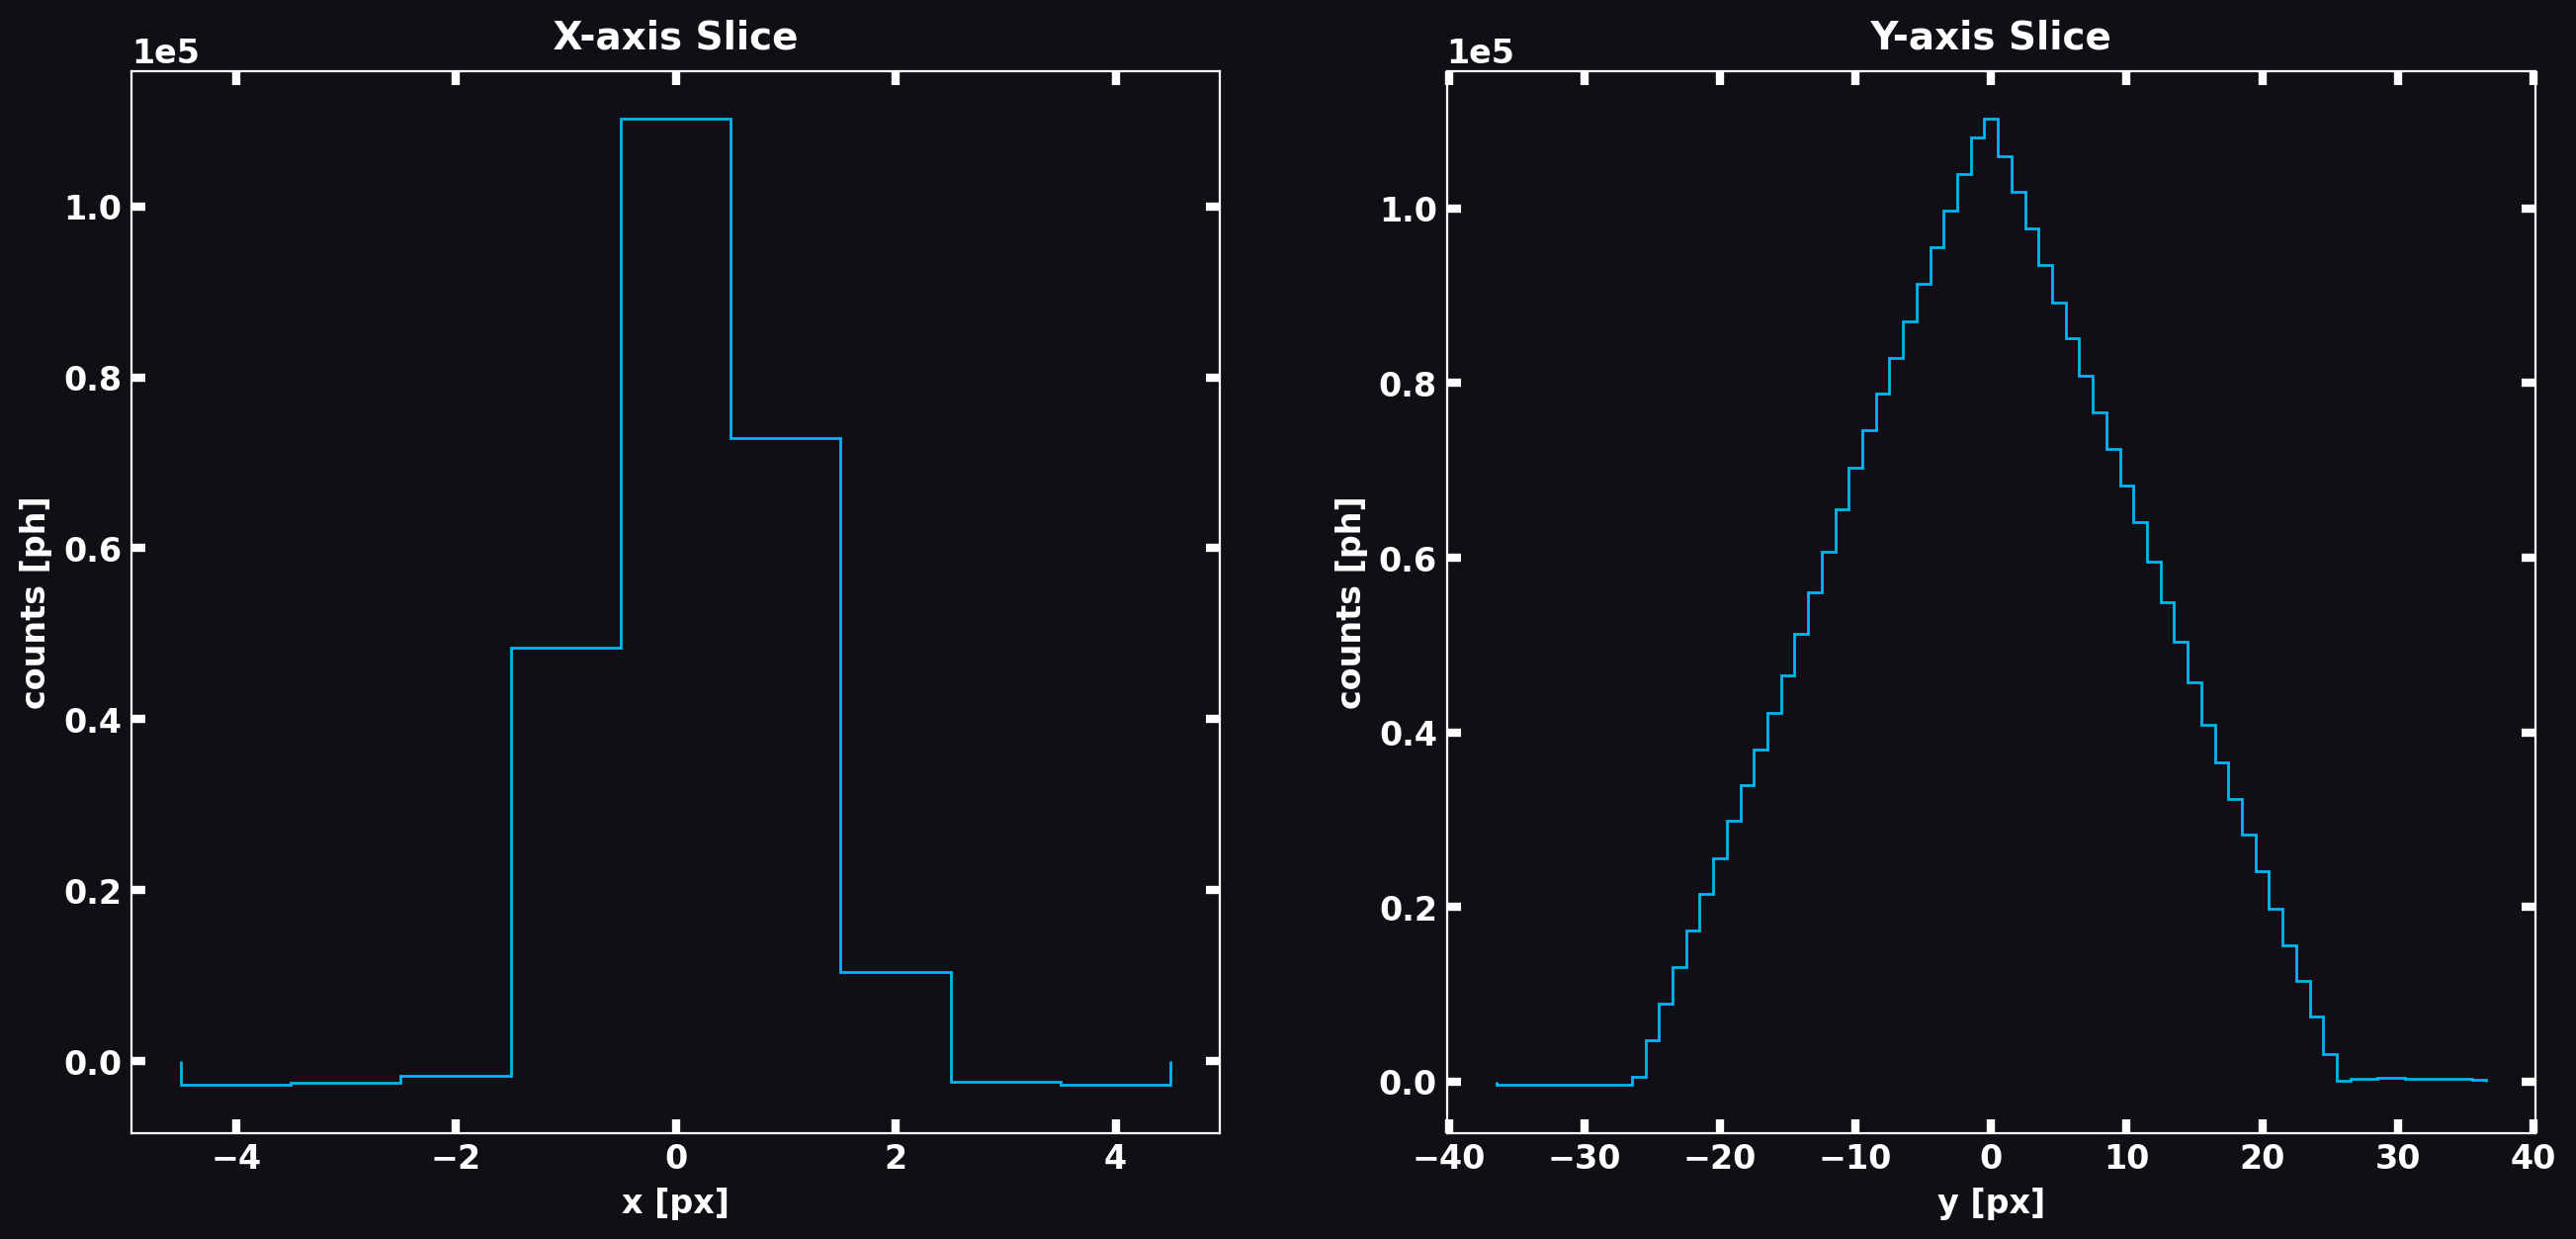

In [ ]:
ds.slices_plot(skymap, find_boxmax(skymap, shift2pos(wfm, sx, sy)), crp=(36, 4), color='DeepSkyBlue')

In [ ]:
def collapse_view(arr: NDArray) -> tuple[NDArray, NDArray]:
    """
    Collapses input 2D array by adding the elements along
    one axis, for both the (x, y) array axes.

    Returns:
        output (tuple[NDArray, NDArray]):
            - collapsed array along the y axis
            - collapsed array along the x axis
    
    ## Notes:
        - if `arr.shape = (n, m)`, the collapsed array
          along y has length `m`, while the collapsed
          array along x has length `n`.
    """
    return np.sum(arr, axis=0), np.sum(arr, axis=1)

def extract_section(
    arr: NDArray,
    rows: slice,
    cols: slice,
) -> NDArray:
    """Returns an array view of the input array."""
    return arr[rows, cols]

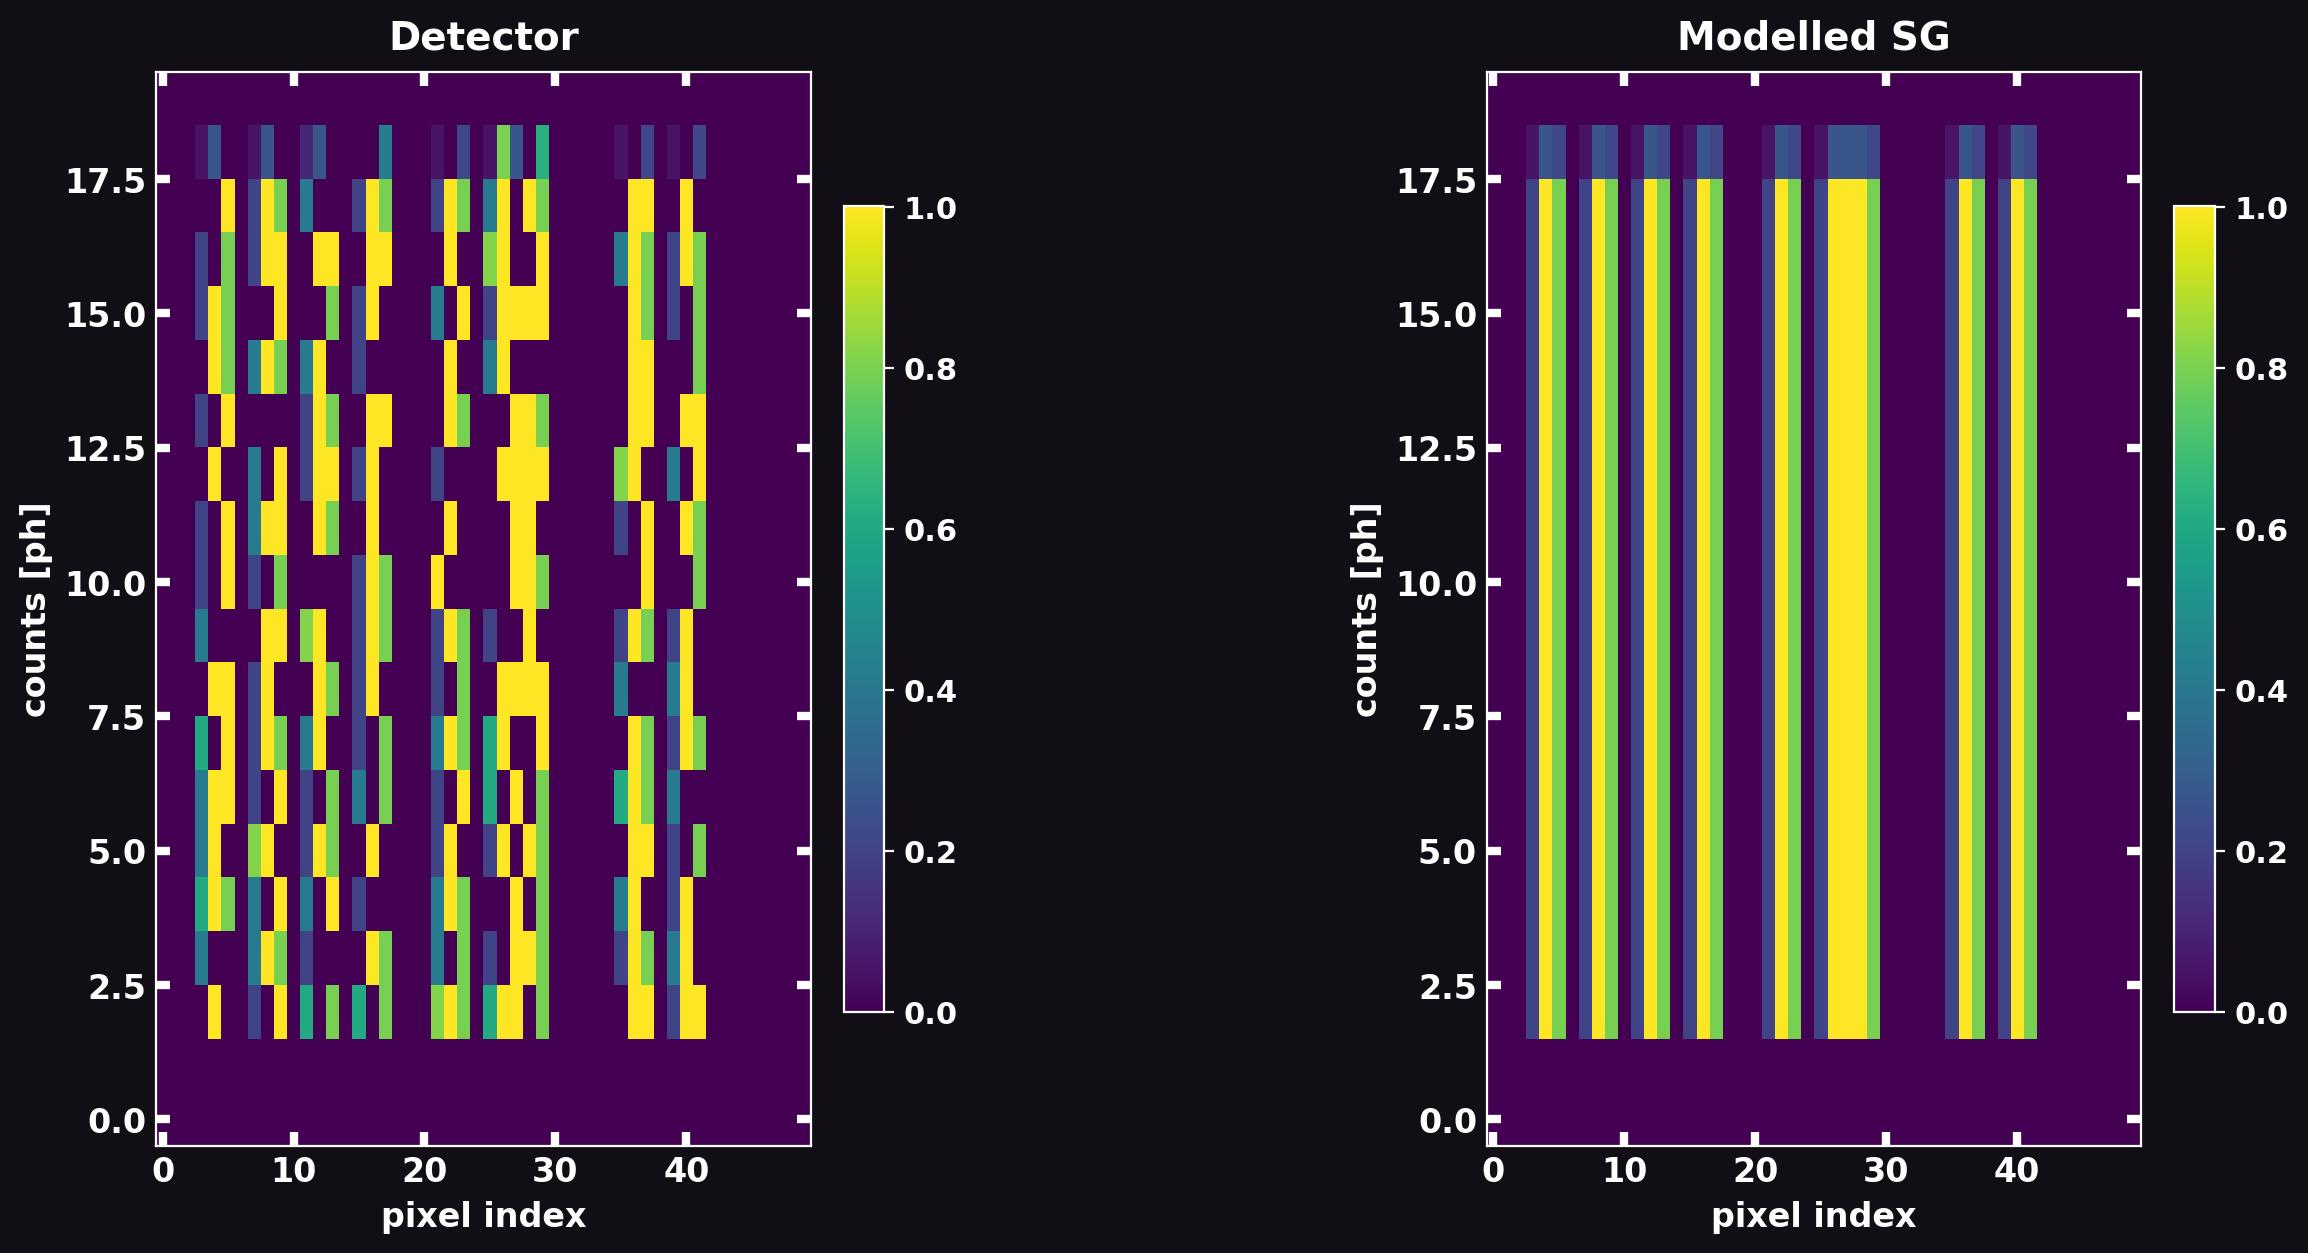

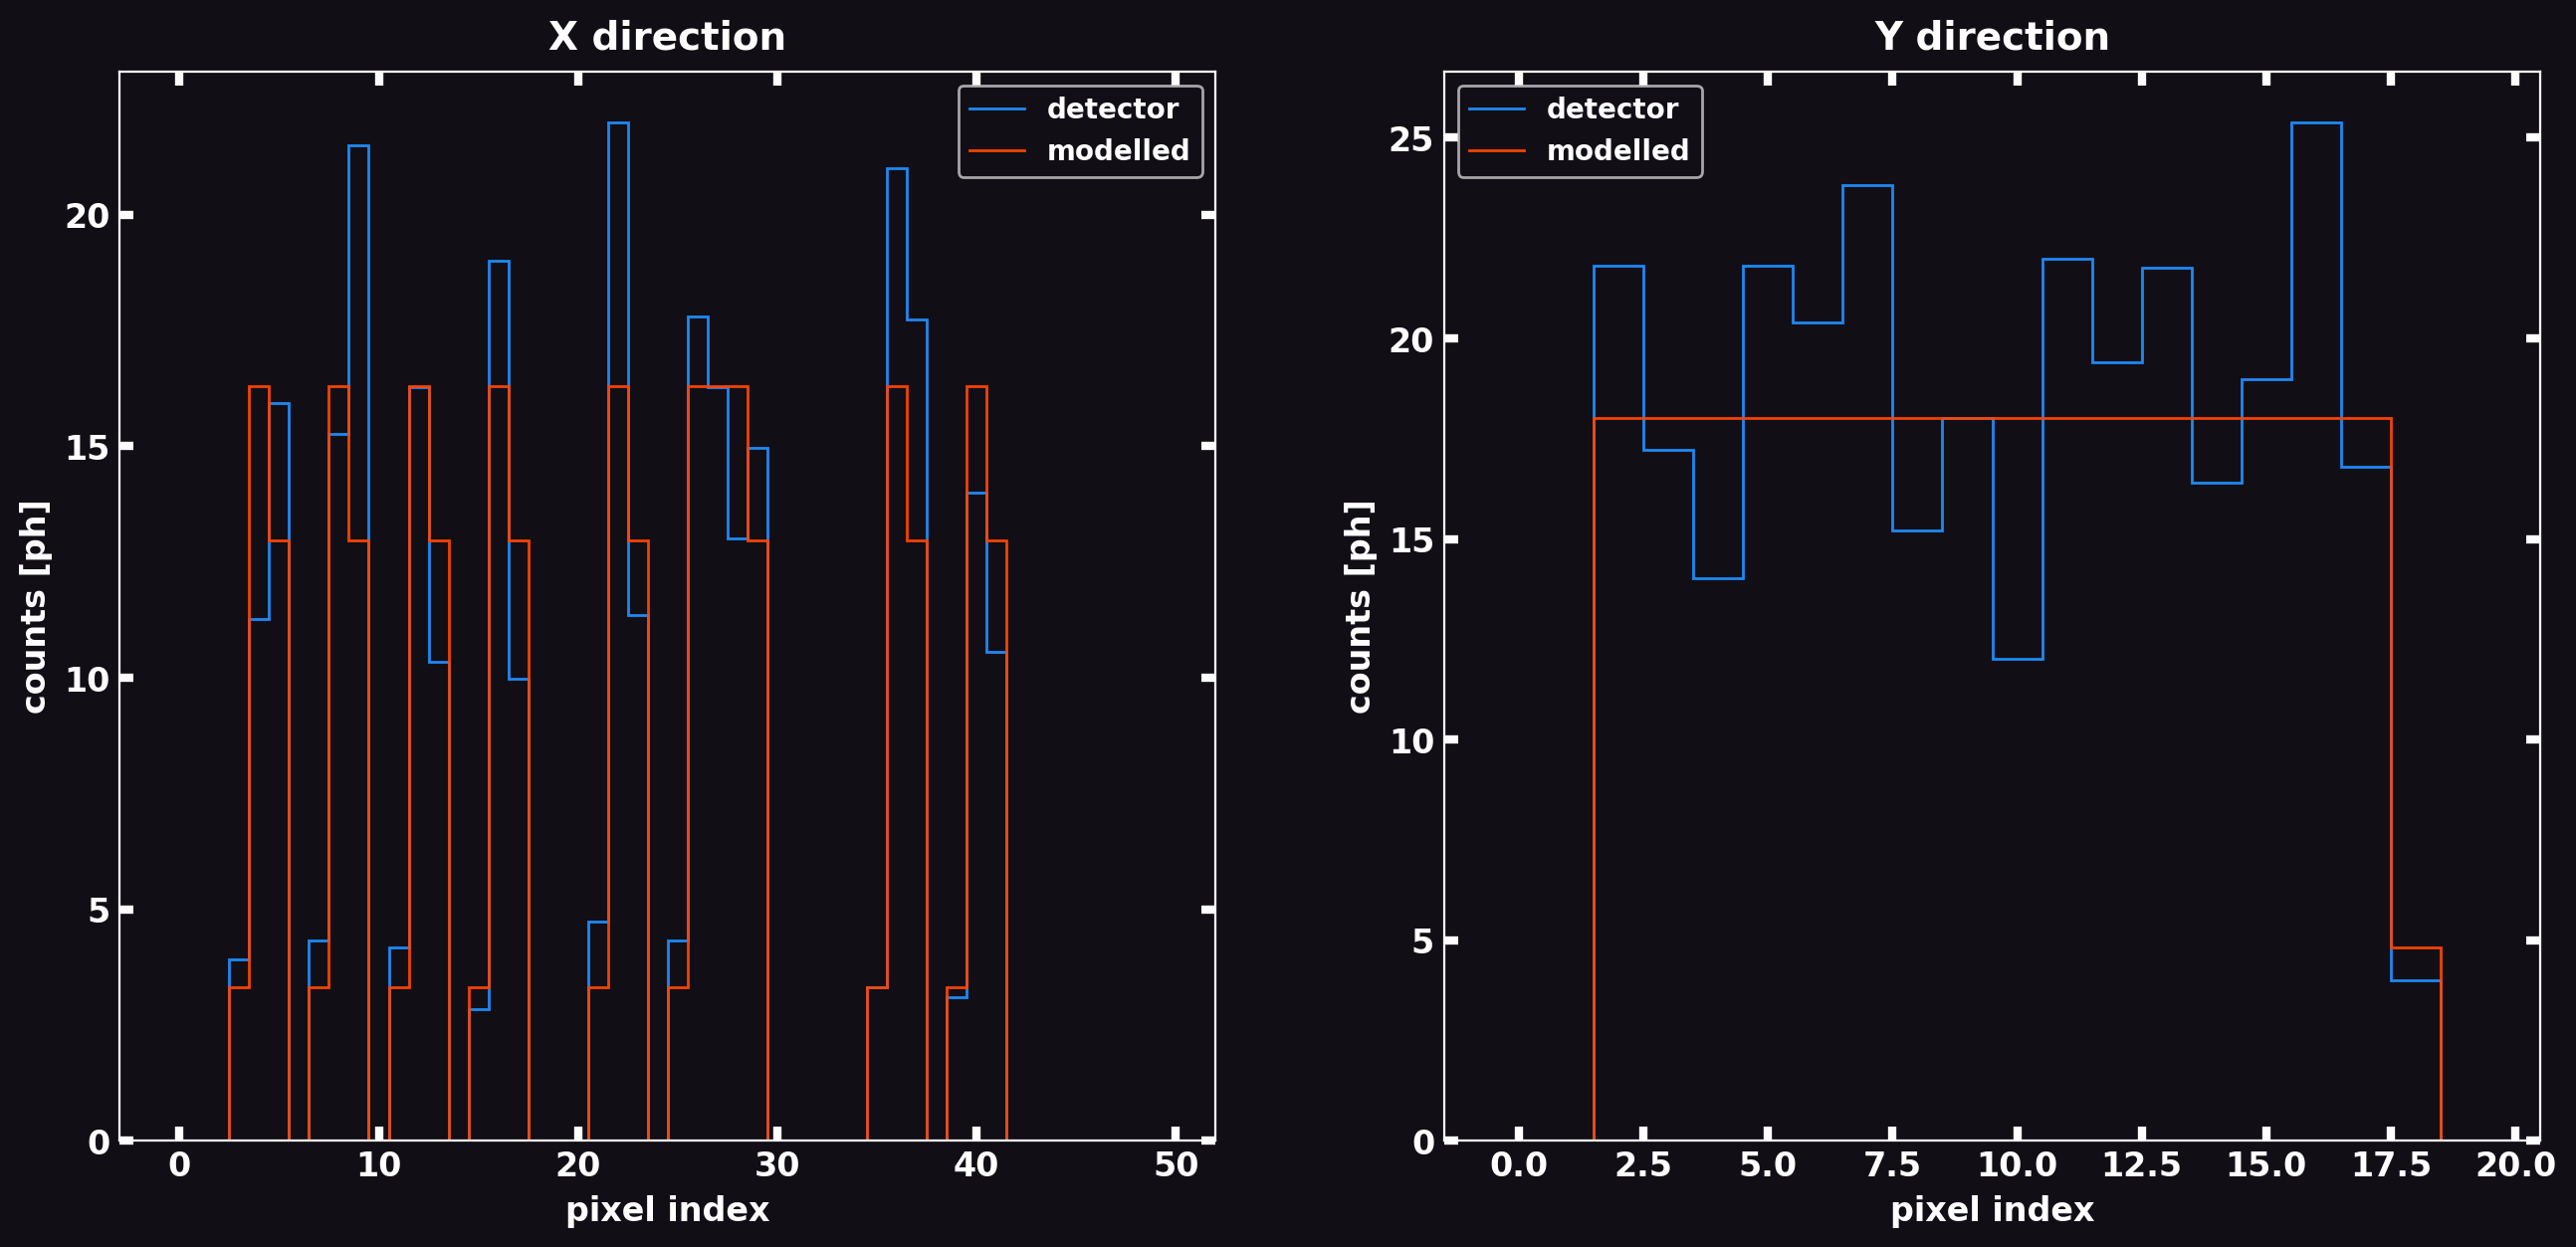

In [ ]:
slicerows, slicecols = slice(165, 185), slice(375, 425)
ext_det, ext_sg = map(
    lambda x: extract_section(x, slicerows, slicecols),
    (detector, sg * detector.sum() / sg.sum()),
)
det_x, det_y = collapse_view(ext_det)
sg_x, sg_y = collapse_view(ext_sg) 

aspect = wfm.shape_detector[1] / wfm.shape_detector[0]
dmap_img_det = ds.map4image(
    img=ext_det,
    title='Detector',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'vmax': ext_sg.max(),
        'aspect': aspect,
    }
)
dmap_img_sg = ds.map4image(
    img=ext_sg,
    title='Modelled SG',
    ylabel='counts [ph]',
    xlabel='pixel index',
    img_kwargs={
        'vmin': 0,
        'aspect': aspect,
    }
)
ds.image_plot((dmap_img_det, dmap_img_sg), ncols=2)

dmap_collapsed_x = ds.map4plot(
    arrs=(det_x, sg_x),
    title='X direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_x, sg_x)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
dmap_collapsed_y = ds.map4plot(
    arrs=(det_y, sg_y),
    title='Y direction',
    ylabel='counts [ph]',
    xlabel='pixel index',
    labels=('detector', 'modelled'),
    x=map(
        lambda x: np.arange(len(x) + 1) - 0.5,
        (det_y, sg_y)
    ),
    color=('DodgerBlue', 'OrangeRed'),
    style='stairs',
)
ds.plot((dmap_collapsed_x, dmap_collapsed_y), ncols=2)